In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("england-counties-to-regions.csv")

# View structure
print(df.head())
print(df.columns)

                    county_name iso_code      region_name region_code  \
0                      Barnsley   GB-BNS       North West   NORTHWEST   
1  Bath and North East Somerset   GB-BAS       South West   SOUTHWEST   
2                       Bedford   GB-BDF  East of England        EAST   
3                    Birmingham   GB-BIR    West Midlands     WESTMID   
4         Blackburn with Darwen   GB-BBD       North West   NORTHWEST   

  population density unknown  rank notes  
0        NaN     NaN     NaN   NaN   NaN  
1    175,500     508     346  66.0   NaN  
2    157,800     331     476  72.0   NaN  
3        NaN     NaN     NaN   NaN   NaN  
4    147,700   1,078     137  77.0   NaN  
Index(['county_name', 'iso_code', 'region_name', 'region_code', 'population',
       'density', 'unknown', 'rank', 'notes'],
      dtype='str')


In [3]:
# Adjust this if your column name is different
text_column = "County" if "County" in df.columns else df.columns[0]

df[text_column] = df[text_column].astype(str)

corpus = df[text_column].values

In [4]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(corpus)

print("Shape of TF-IDF matrix:", X.shape)

Shape of TF-IDF matrix: (127, 183)


In [5]:
# Choose number of clusters (England has ~9 regions typically)
k = 9

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

df["Cluster"] = clusters
df.head()

,county_name,iso_code,region_name,region_code,population,density,unknown,rank,notes,Cluster
0,Barnsley,GB-BNS,North West,NORTHWEST,NaN,NaN,NaN,NaN,NaN,1
1,Bath and North East Somerset,GB-BAS,South West,SOUTHWEST,"175,500",508,346,66.0,NaN,0
2,Bedford,GB-BDF,East of England,EAST,"157,800",331,476,72.0,NaN,4
3,Birmingham,GB-BIR,West Midlands,WESTMID,NaN,NaN,NaN,NaN,NaN,1
4,Blackburn with Darwen,GB-BBD,North West,NORTHWEST,"147,700","1,078",137,77.0,NaN,1


In [6]:
if "Region" in df.columns:
    print(pd.crosstab(df["Region"], df["Cluster"]))

In [7]:
pca = PCA(n_components=2)
X_dense = X.toarray()  # convert sparse → dense for PCA

coords = pca.fit_transform(X_dense)

df["PCA1"] = coords[:, 0]
df["PCA2"] = coords[:, 1]

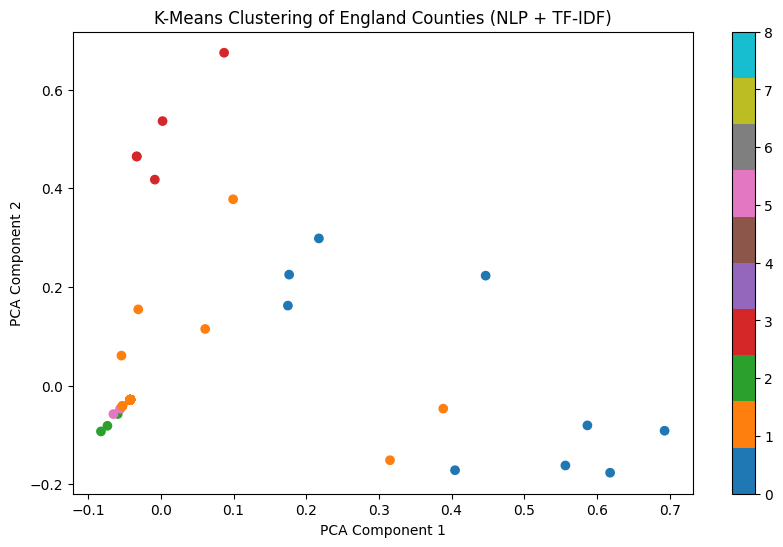

In [8]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df["PCA1"],
    df["PCA2"],
    c=df["Cluster"],
    cmap="tab10"
)

plt.title("K-Means Clustering of England Counties (NLP + TF-IDF)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter)
plt.show()

In [9]:
for i in range(k):
    print(f"\nCluster {i}")
    print(df[df["Cluster"] == i][text_column].head(10).values)


Cluster 0
<ArrowStringArray>
['Bath and North East Somerset',                'Cheshire East',
     'East Riding of Yorkshire',                  'East Sussex',
                 'Lincolnshire',      'North East Lincolnshire',
           'North Lincolnshire',               'North Somerset',
              'North Yorkshire']
Length: 9, dtype: str

Cluster 1
<ArrowStringArray>
[             'Barnsley',            'Birmingham', 'Blackburn with Darwen',
             'Blackpool',                'Bolton',           'Bournemouth',
      'Bracknell Forest',              'Bradford',     'Brighton and Hove',
               'Bristol']
Length: 10, dtype: str

Cluster 2
<ArrowStringArray>
['County Durham', 'County of Herefordshire', 'Herefordshire']
Length: 3, dtype: str

Cluster 3
<ArrowStringArray>
['Cheshire West and Chester',            'West Berkshire',
             'West Midlands',               'West Sussex',
            'West Yorkshire']
Length: 5, dtype: str

Cluster 4
<ArrowStringArray>
['Be